## movie recommendation data

Importing the dependencies

In [ ]:
import numpy as np
import pandas as pd
import difflib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## Data Loading

Data Collection and Pre-Processing

In [ ]:
# loading the data from the csv file to apandas dataframe
movies_data = pd.read_csv('/content/movies.csv')

In [ ]:
# printing the first 5 rows of the dataframe
movies_data.head()

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


In [ ]:
# number of rows and columns in the data frame

movies_data.shape

(4803, 24)

2. Data Cleaning
Removing duplicates and handling missing values.

In [ ]:
# removing duplicates
movies_data = movies_data.drop_duplicates()


In [ ]:
# selecting the relevant features for recommendation

selected_features = ['genres','keywords','tagline','cast','director']
print(selected_features)

['genres', 'keywords', 'tagline', 'cast', 'director']


In [ ]:
# replacing the null valuess with null string

for feature in selected_features:
  movies_data[feature] = movies_data[feature].fillna('')

In [ ]:
# combining all the 5 selected features

combined_features = movies_data['genres']+' '+movies_data['keywords']+' '+movies_data['tagline']+' '+movies_data['cast']+' '+movies_data['director']

In [ ]:
print(combined_features)

0       Action Adventure Fantasy Science Fiction cultu...
1       Adventure Fantasy Action ocean drug abuse exot...
2       Action Adventure Crime spy based on novel secr...
3       Action Crime Drama Thriller dc comics crime fi...
4       Action Adventure Science Fiction based on nove...
                              ...                        
4798    Action Crime Thriller united states\u2013mexic...
4799    Comedy Romance  A newlywed couple's honeymoon ...
4800    Comedy Drama Romance TV Movie date love at fir...
4801      A New Yorker in Shanghai Daniel Henney Eliza...
4802    Documentary obsession camcorder crush dream gi...
Length: 4803, dtype: object


## 3. Feature Engineering
•	Convert text data (genres, tags) into vectors


In [ ]:
# converting the text data to feature vectors

vectorizer = TfidfVectorizer()

In [ ]:
feature_vectors = vectorizer.fit_transform(combined_features)

In [ ]:
print(feature_vectors)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 124266 stored elements and shape (4803, 17318)>
  Coords	Values
  (0, 201)	0.07860022416510505
  (0, 274)	0.09021200873707368
  (0, 5274)	0.11108562744414445
  (0, 13599)	0.1036413987316636
  (0, 5437)	0.1036413987316636
  (0, 3678)	0.21392179219912877
  (0, 3065)	0.22208377802661425
  (0, 5836)	0.1646750903586285
  (0, 14378)	0.33962752210959823
  (0, 16587)	0.12549432354918996
  (0, 3225)	0.24960162956997736
  (0, 14271)	0.21392179219912877
  (0, 4945)	0.24025852494110758
  (0, 15261)	0.07095833561276566
  (0, 16998)	0.1282126322850579
  (0, 11192)	0.09049319826481456
  (0, 11503)	0.27211310056983656
  (0, 13349)	0.15021264094167086
  (0, 17007)	0.23643326319898797
  (0, 17290)	0.20197912553916567
  (0, 13319)	0.2177470539412484
  (0, 14064)	0.20596090415084142
  (0, 16668)	0.19843263965100372
  (0, 14608)	0.15150672398763912
  (0, 8756)	0.22709015857011816
  :	:
  (4801, 403)	0.17727585190343229
  (4801, 4835)	0.247137650

# 4. Model Building
Cosine Similarity

Content-Based Filtering using Cosine Similarity

In [ ]:
# getting the similarity scores using cosine similarity

similarity = cosine_similarity(feature_vectors)

In [ ]:
print(similarity)

[[1.         0.07219487 0.037733   ... 0.         0.         0.        ]
 [0.07219487 1.         0.03281499 ... 0.03575545 0.         0.        ]
 [0.037733   0.03281499 1.         ... 0.         0.05389661 0.        ]
 ...
 [0.         0.03575545 0.         ... 1.         0.         0.02651502]
 [0.         0.         0.05389661 ... 0.         1.         0.        ]
 [0.         0.         0.         ... 0.02651502 0.         1.        ]]


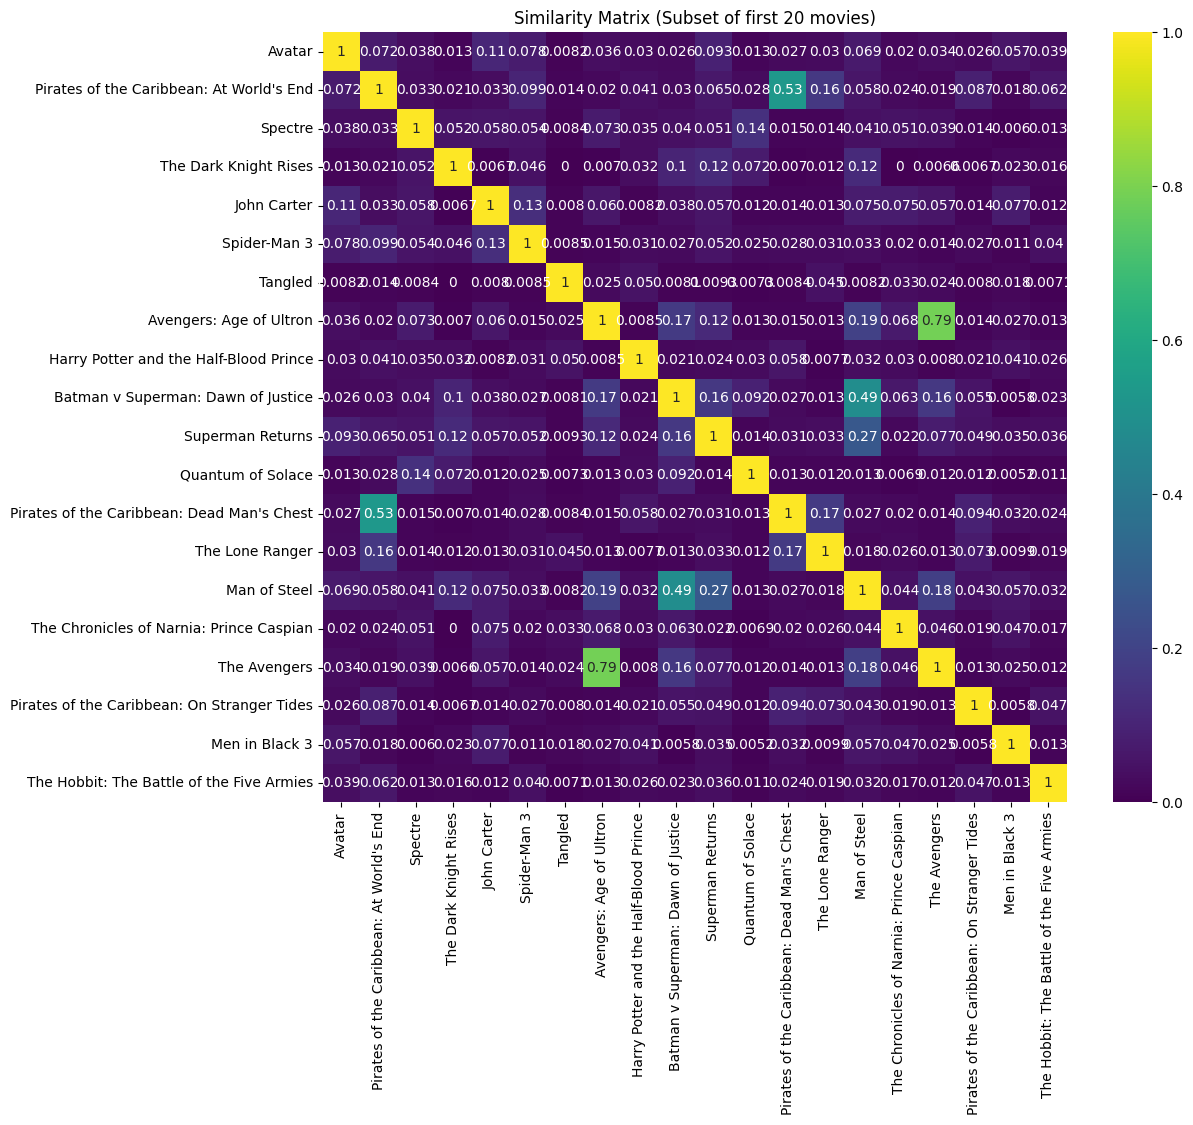

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize a subset of the similarity matrix (e.g., the first 20 movies)
plt.figure(figsize=(12, 10))
sns.heatmap(similarity[:20, :20], annot=True, cmap='viridis',
            xticklabels=list_of_all_titles[:20],
            yticklabels=list_of_all_titles[:20])
plt.title('Similarity Matrix (Subset of first 20 movies)')
plt.show()

In [ ]:
print(similarity.shape)

(4803, 4803)


## 5.Recommendation Logic
Getting the movie name from the user

In [ ]:
# getting the movie name from the user

movie_name = input(' Enter your favourite movie name : ')

 Enter your favourite movie name : Guardian of the Galaxy


In [ ]:
# creating a list with all the movie names given in the dataset

list_of_all_titles = movies_data['title'].tolist()
print(list_of_all_titles)

['Avatar', "Pirates of the Caribbean: At World's End", 'Spectre', 'The Dark Knight Rises', 'John Carter', 'Spider-Man 3', 'Tangled', 'Avengers: Age of Ultron', 'Harry Potter and the Half-Blood Prince', 'Batman v Superman: Dawn of Justice', 'Superman Returns', 'Quantum of Solace', "Pirates of the Caribbean: Dead Man's Chest", 'The Lone Ranger', 'Man of Steel', 'The Chronicles of Narnia: Prince Caspian', 'The Avengers', 'Pirates of the Caribbean: On Stranger Tides', 'Men in Black 3', 'The Hobbit: The Battle of the Five Armies', 'The Amazing Spider-Man', 'Robin Hood', 'The Hobbit: The Desolation of Smaug', 'The Golden Compass', 'King Kong', 'Titanic', 'Captain America: Civil War', 'Battleship', 'Jurassic World', 'Skyfall', 'Spider-Man 2', 'Iron Man 3', 'Alice in Wonderland', 'X-Men: The Last Stand', 'Monsters University', 'Transformers: Revenge of the Fallen', 'Transformers: Age of Extinction', 'Oz: The Great and Powerful', 'The Amazing Spider-Man 2', 'TRON: Legacy', 'Cars 2', 'Green Lant

In [ ]:
# finding the close match for the movie name given by the user

find_close_match = difflib.get_close_matches(movie_name, list_of_all_titles)
print(find_close_match)

['Guardians of the Galaxy', 'Survival of the Dead', 'Chairman of the Board']


In [ ]:
close_match = find_close_match[0]
print(close_match)

Guardians of the Galaxy


In [ ]:
# finding the index of the movie with title

index_of_the_movie = movies_data[movies_data.title == close_match]['index'].values[0]
print(index_of_the_movie)

94


In [ ]:
# getting a list of similar movies

similarity_score = list(enumerate(similarity[index_of_the_movie]))
print(similarity_score)

[(0, np.float64(0.24505931974059822)), (1, np.float64(0.019052413276307974)), (2, np.float64(0.014239357082368585)), (3, np.float64(0.006706048123274194)), (4, np.float64(0.08848380686968997)), (5, np.float64(0.02723201939755145)), (6, np.float64(0.008007726303660537)), (7, np.float64(0.17202144995270482)), (8, np.float64(0.008171535826638276)), (9, np.float64(0.044602865830179084)), (10, np.float64(0.053058160754853104)), (11, np.float64(0.012363550698898851)), (12, np.float64(0.014210451811523809)), (13, np.float64(0.024233788161169056)), (14, np.float64(0.0656829911302823)), (15, np.float64(0.007553552143654802)), (16, np.float64(0.16311290114551133)), (17, np.float64(0.013593946865507685)), (18, np.float64(0.025691911937934804)), (19, np.float64(0.012069219203384569)), (20, np.float64(0.08273945378774945)), (21, np.float64(0.01168017361224877)), (22, np.float64(0.025621231274005292)), (23, np.float64(0.02203576893387762)), (24, np.float64(0.013129803286822773)), (25, np.float64(0.0

In [ ]:
len(similarity_score)

4803

In [ ]:
# sorting the movies based on their similarity score

sorted_similar_movies = sorted(similarity_score, key = lambda x:x[1], reverse = True)
print(sorted_similar_movies)

[(94, np.float64(1.0000000000000002)), (0, np.float64(0.24505931974059822)), (223, np.float64(0.22079394022167553)), (56, np.float64(0.21781439485487547)), (47, np.float64(0.2150056036367402)), (1531, np.float64(0.2049820945691705)), (977, np.float64(0.2044772347659412)), (1951, np.float64(0.18952848550963272)), (85, np.float64(0.17967606391016483)), (3158, np.float64(0.17229440417519018)), (7, np.float64(0.17202144995270482)), (1650, np.float64(0.17147975512268793)), (182, np.float64(0.16961810962450952)), (239, np.float64(0.16955969984060348)), (16, np.float64(0.16311290114551133)), (3730, np.float64(0.16230307970921318)), (169, np.float64(0.16048463314930617)), (661, np.float64(0.1594476217195789)), (4401, np.float64(0.15038090968886206)), (643, np.float64(0.14730566749278845)), (46, np.float64(0.14193109457292374)), (184, np.float64(0.141749776499168)), (3474, np.float64(0.13938174430990302)), (511, np.float64(0.13784364082232986)), (3405, np.float64(0.13771051997373931)), (68, np.

In [ ]:
# print the name of similar movies based on the index

print('Movies suggested for you : \n')

i = 1

for movie in sorted_similar_movies:
  index = movie[0]
  title_from_index = movies_data[movies_data.index==index]['title'].values[0]
  if (i<30):
    print(i, '.',title_from_index)
    i+=1

Movies suggested for you : 

1 . Guardians of the Galaxy
2 . Avatar
3 . The Chronicles of Riddick
4 . Star Trek Beyond
5 . Star Trek Into Darkness
6 . Moonraker
7 . The Iron Giant
8 . Space Dogs
9 . Captain America: The Winter Soldier
10 . Alien
11 . Avengers: Age of Ultron
12 . Wing Commander
13 . Ant-Man
14 . Gravity
15 . The Avengers
16 . Cargo
17 . Captain America: The First Avenger
18 . Zathura: A Space Adventure
19 . The Helix... Loaded
20 . Space Cowboys
21 . X-Men: Days of Future Past
22 . Home
23 . The Words
24 . X-Men
25 . Stargate: The Ark of Truth
26 . Iron Man
27 . X-Men: Apocalypse
28 . Jason X
29 . X-Men: The Last Stand


## 6.Output

Movie Recommendation Sytem

favourite movie - Guardian of the Galaxy

In [ ]:
movie_name = input(' Enter your favourite movie name : ')

list_of_all_titles = movies_data['title'].tolist()

find_close_match = difflib.get_close_matches(movie_name, list_of_all_titles)

close_match = find_close_match[0]

index_of_the_movie = movies_data[movies_data.title == close_match]['index'].values[0]

similarity_score = list(enumerate(similarity[index_of_the_movie]))

sorted_similar_movies = sorted(similarity_score, key = lambda x:x[1], reverse = True)

print('Movies suggested for you : \n')

i = 1

for movie in sorted_similar_movies:
  index = movie[0]
  title_from_index = movies_data[movies_data.index==index]['title'].values[0]
  if (i<30):
    print(i, '.',title_from_index)
    i+=1

 Enter your favourite movie name : Guardian of the Galaxy
Movies suggested for you : 

1 . Guardians of the Galaxy
2 . Avatar
3 . The Chronicles of Riddick
4 . Star Trek Beyond
5 . Star Trek Into Darkness
6 . Moonraker
7 . The Iron Giant
8 . Space Dogs
9 . Captain America: The Winter Soldier
10 . Alien
11 . Avengers: Age of Ultron
12 . Wing Commander
13 . Ant-Man
14 . Gravity
15 . The Avengers
16 . Cargo
17 . Captain America: The First Avenger
18 . Zathura: A Space Adventure
19 . The Helix... Loaded
20 . Space Cowboys
21 . X-Men: Days of Future Past
22 . Home
23 . The Words
24 . X-Men
25 . Stargate: The Ark of Truth
26 . Iron Man
27 . X-Men: Apocalypse
28 . Jason X
29 . X-Men: The Last Stand


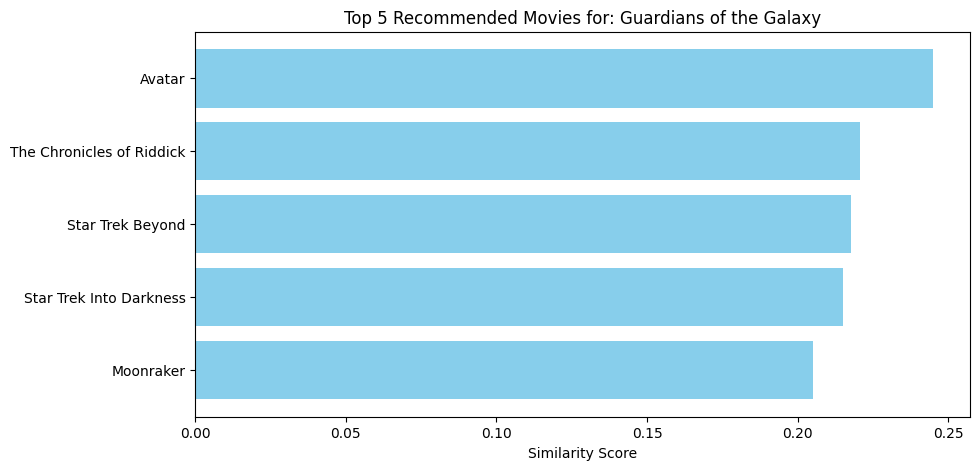

In [ ]:
import matplotlib.pyplot as plt

# Get the top 5 movies (excluding the movie itself at index 0)
top_5_suggestions = sorted_similar_movies[1:6]

titles = []
scores = []

for movie in top_5_suggestions:
    index = movie[0]
    titles.append(movies_data[movies_data.index == index]['title'].values[0])
    scores.append(movie[1])

# Plotting the results
plt.figure(figsize=(10, 5))
plt.barh(titles[::-1], scores[::-1], color='skyblue')
plt.xlabel('Similarity Score')
plt.title('Top 5 Recommended Movies for: ' + close_match)
plt.show()